**Laboratorio #3 - Clasificación de texto**

Juan Diego Letona Aguilar

*20230285*

In [39]:
#parcialmente reciclado del notebook 1 y 2

import sys
import subprocess

packages = [
    "pandas",
    "numpy",
    "nltk",
    "matplotlib",
    "wordcloud",
    "spacy",
    "tqdm"
]

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-U", *packages
])

# Modelo pequeño de spaCy para español
subprocess.check_call([
    sys.executable, "-m", "spacy", "download", "es_core_news_sm"
])

0

In [40]:
from pathlib import Path
from collections import Counter
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

#voy a usar spacy porque el corpus es en español y spacy tiene un modelo para español
#otros modelos suelen funcionar mejor para el idioma ingles
#depende del caso de uso

import spacy
from tqdm import tqdm
from wordcloud import WordCloud

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

#recursos de NLTK
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [41]:
import pandas as pd

df = pd.read_csv("df_total.csv")
#leemos el archivo csv y lo guardamos en un DataFrame de pandas

print("Dimensiones del DataFrame:", df.shape)
display(df.head())

Dimensiones del DataFrame: (1217, 3)


,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de BBVA en Colomb...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bo...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como lo es la aviación Viva presentó su avión rosado A320NEO que apuesta por la equidad de género la luc...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encadena su decimoquinta tasa positiva consecutiva. La inflación publicada por el INE se ha mantenido igual...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión número 56 de la Convención Bancaria. Este será el primer encuentro de los banqueros del país con el p...,Otra


In [42]:
#configuracion y descripcion de columnas

URL_COL = "url"
TEXT_COL = "news"
CATEGORY_COL = "Type"

descripcion = {
    URL_COL: "enlace original de la noticia",
    TEXT_COL: "contenido textual de la noticia",
    CATEGORY_COL: "categoria asignada a la noticia"
}

columnas = pd.DataFrame({
    "columna": descripcion.keys(),
    "tipo_de_dato": [str(df[col].dtype) for col in descripcion],
    "informacion": descripcion.values()
})

display(
    columnas.style
    .hide(axis="index")
    .set_caption("Columnas del corpus")
)

columna,tipo_de_dato,informacion
url,str,enlace original de la noticia
news,str,contenido textual de la noticia
Type,str,categoria asignada a la noticia


In [43]:
#preparamos el corpus para el procesamiento

corpus = df[[URL_COL, TEXT_COL, CATEGORY_COL]].copy()

corpus[TEXT_COL] = corpus[TEXT_COL].fillna("").astype(str)
corpus = corpus[corpus[TEXT_COL].str.strip().ne("")]
corpus = corpus.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)

stopwords_es = set(stopwords.words("spanish"))

#basicamente quitamos la puntuacion de los tokens, para que no afecte el conteo de palabras y tipos de palabras

def quitar_puntuacion(token):
    return "".join(
        caracter for caracter in token
        if not unicodedata.category(caracter).startswith("P")
    ).strip()

def contar_tokens_tipos(columna):
    tokens = [token for documento in columna for token in documento]
    return len(tokens), len(set(tokens))

print("Documentos que serán procesados:", len(corpus))

Documentos que serán procesados: 1137


In [44]:
#tokenizacion

tqdm.pandas(desc="Tokenizando")

corpus["tokens_tokenizados"] = corpus[TEXT_COL].progress_apply(
    lambda texto: word_tokenize(texto, language="spanish")
)

#minusculas

corpus["tokens_minusculas"] = corpus["tokens_tokenizados"].apply(
    lambda tokens: [token.lower() for token in tokens]
)

#eliminacion de puntuacion

corpus["tokens_sin_puntuacion"] = corpus["tokens_minusculas"].apply(
    lambda tokens: [
        limpio for token in tokens
        if (limpio := quitar_puntuacion(token))
    ]
)

#eliminacion de stopwords

corpus["tokens_sin_stopwords"] = corpus["tokens_sin_puntuacion"].apply(
    lambda tokens: [token for token in tokens if token not in stopwords_es]
)

Tokenizando: 100%|██████████| 1137/1137 [00:01<00:00, 747.40it/s]


In [45]:
#lematizacion
nlp = spacy.load(
    "es_core_news_sm",
    disable=["parser", "ner"]
)

textos = corpus["tokens_sin_stopwords"].apply(" ".join)

corpus["tokens_lematizados"] = [
    [
        token.lemma_.lower()
        for token in documento
        if token.lemma_.strip()
    ]
    for documento in tqdm(
        nlp.pipe(textos, batch_size=64),
        total=len(textos),
        desc="Lematizando"
    )
]

Lematizando: 100%|██████████| 1137/1137 [00:16<00:00, 67.95it/s] 


In [46]:
#texto normalizado por documento

corpus["texto_normalizado"] = corpus["tokens_lematizados"].apply(
    lambda tokens: " ".join(tokens)
)

display(
    corpus[
        [
            TEXT_COL,
            CATEGORY_COL,
            "tokens_lematizados",
            "texto_normalizado"
        ]
    ].head()
)

,news,Type,tokens_lematizados,texto_normalizado
0,Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de BBVA en Colomb...,Otra,"[foro, banca, articulador, empresarial, desarrollo, sostenible, director, sostenibilidad, cliente, global, bbva, colombia, andrés, garcía, asegura...",foro banca articulador empresarial desarrollo sostenible director sostenibilidad cliente global bbva colombia andrés garcía asegurar importante en...
1,El regulador de valores de China dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bo...,Regulaciones,"[regulador, valor, chino, decir, domingo, buscar, cooperación, estrecho, par, estadounidense, apoyar, salida, bolso, extranjero, luego, supervisor...",regulador valor chino decir domingo buscar cooperación estrecho par estadounidense apoyar salida bolso extranjero luego supervisor estadounidense ...
2,En una industria históricamente masculina como lo es la aviación Viva presentó su avión rosado A320NEO que apuesta por la equidad de género la luc...,Alianzas,"[industria, históricamente, masculino, aviación, vivo, presentar, avión, rosado, a320neo, apostar, equidad, género, lucha, cáncer, mama, inclusión...",industria históricamente masculino aviación vivo presentar avión rosado a320neo apostar equidad género lucha cáncer mama inclusión diversidaddesde...
3,Con el dato de marzo el IPC interanual encadena su decimoquinta tasa positiva consecutiva. La inflación publicada por el INE se ha mantenido igual...,Macroeconomia,"[dato, marzo, ipc, interanual, encadenar, decimoquinto, tasa, positivo, consecutivo, inflación, publicado, ine, mantenido, igual, respecto, avance...",dato marzo ipc interanual encadenar decimoquinto tasa positivo consecutivo inflación publicado ine mantenido igual respecto avance 30 marzo situar...
4,Ayer en Cartagena se dio inicio a la versión número 56 de la Convención Bancaria. Este será el primer encuentro de los banqueros del país con el p...,Otra,"[ayer, cartagena, dar, inicio, versión, número, 56, convención, bancario, primero, encuentro, banquero, país, presidente, gustavo, petro, sesión, ...",ayer cartagena dar inicio versión número 56 convención bancario primero encuentro banquero país presidente gustavo petro sesión clausura próximo v...


**1. Conjuntos de entrenamiento, validación y prueba**

In [47]:
from sklearn.model_selection import train_test_split

#preparamos el texto normalizado y las categorias para el aprendizaje supervisado

X = corpus["texto_normalizado"]
y = corpus[CATEGORY_COL]

print("Numero total de documentos:", len(X))
print("Numero de categorias:", y.nunique())

Numero total de documentos: 1137
Numero de categorias: 7


In [48]:
#dividimos primero el corpus en 70% entrenamiento y 30% temporal

X_entrenamiento, X_temporal, y_entrenamiento, y_temporal = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

#dividimos el 30% temporal en partes iguales para validacion y prueba

X_validacion, X_prueba, y_validacion, y_prueba = train_test_split(
    X_temporal,
    y_temporal,
    test_size=0.50,
    random_state=42,
    stratify=y_temporal
)

In [49]:
#verificamos el tamano de cada conjunto

resumen_conjuntos = pd.DataFrame({
    "conjunto": [
        "Entrenamiento",
        "Validacion",
        "Prueba"
    ],
    "documentos": [
        len(X_entrenamiento),
        len(X_validacion),
        len(X_prueba)
    ]
})

#y aqui calculamos el porcentaje de documentos en cada conjunto con respecto al total del corpus
resumen_conjuntos["porcentaje_%"] = (
    resumen_conjuntos["documentos"]
    / len(corpus)
    * 100
).round(2)

display(
    resumen_conjuntos.style
    .hide(axis="index")
    .set_caption("Distribución de documentos por conjunto")
)

conjunto,documentos,porcentaje_%
Entrenamiento,795,69.920000
Validacion,171,15.040000
Prueba,171,15.040000


In [50]:
#comparamos la distribucion de categorias entre los tres conjuntos

distribucion_categorias = pd.concat(
    [
        y_entrenamiento.value_counts().rename("Entrenamiento"),
        y_validacion.value_counts().rename("Validacion"),
        y_prueba.value_counts().rename("Prueba")
    ],
    axis=1
).fillna(0).astype(int)

display(
    distribucion_categorias.style
    .set_caption("Cantidad de documentos por categoría")
)

,Entrenamiento,Validacion,Prueba
Type,,,
Macroeconomia,223,48,48
Alianzas,172,37,37
Innovacion,106,23,23
Regulaciones,99,21,21
Otra,90,19,20
Sostenibilidad,87,19,18
Reputacion,18,4,4


In [51]:
#comparamos los porcentajes de cada categoria para verificar la estratificacion

distribucion_porcentual = pd.concat(
    [
        y_entrenamiento.value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename("Entrenamiento_%"),

        y_validacion.value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename("Validacion_%"),

        y_prueba.value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename("Prueba_%")
    ],
    axis=1
)

display(
    distribucion_porcentual.style
    .set_caption("Distribución porcentual de categorías")
)

,Entrenamiento_%,Validacion_%,Prueba_%
Type,,,
Macroeconomia,28.050000,28.070000,28.070000
Alianzas,21.640000,21.640000,21.640000
Innovacion,13.330000,13.450000,13.450000
Regulaciones,12.450000,12.280000,12.280000
Otra,11.320000,11.110000,11.700000
Sostenibilidad,10.940000,11.110000,10.530000
Reputacion,2.260000,2.340000,2.340000


El conjunto de entrenamiento contiene los documentos que el modelo utiliza para aprender los patrones que permiten relacionar el texto de una noticia con su categoria. El conjunto de validacion contiene documentos que no se utilizan directamente para entrenar el modelo. Este conjunto sirve para comparar distintas configuraciones y tomar decisiones durante el desarrollo, por ejemplo seleccionar parametros o determinar cual modelo produce mejores resultados. Por ultimo, el conjunto de prueba se utiliza para realizar la evaluacion final del modelo con documentos que no fueron utilizados durante el entrenamiento ni para tomar decisiones durante la validacion. No se debe utilizar este conjunto para ajustar el modelo porque entonces los resultados dejarian de representar correctamente su desempeño sobre datos realmente desconocidos.

**2. Construcción del clasificador Naive Bayes**

In [52]:
#creamos la representacion de bolsa de palabras utilizando el texto ya normalizado

from sklearn.feature_extraction.text import CountVectorizer

#aqui definimos el vectorizador de la bosla de palabras con un tokenizador que separa las tokens por espacios
#pero sin aplicar transformaciones como pasar a minusculas o eliminar puntuacion

vectorizador_bow = CountVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    lowercase=False
)

#entrenamos el vectorizador con el conjunto de entrenamiento y transformamos los tres conjuntos
matriz_bow_entrenamiento = vectorizador_bow.fit_transform(
    X_entrenamiento
)

matriz_bow_validacion = vectorizador_bow.transform(
    X_validacion
)

matriz_bow_prueba = vectorizador_bow.transform(
    X_prueba
)

print("Forma de la matriz BoW de entrenamiento:", matriz_bow_entrenamiento.shape)
print("Forma de la matriz BoW de validacion:", matriz_bow_validacion.shape)
print("Forma de la matriz BoW de prueba:", matriz_bow_prueba.shape)
print("Tamaño del vocabulario:", matriz_bow_entrenamiento.shape[1])

Forma de la matriz BoW de entrenamiento: (795, 22066)
Forma de la matriz BoW de validacion: (171, 22066)
Forma de la matriz BoW de prueba: (171, 22066)
Tamaño del vocabulario: 22066


In [53]:
#clasificador Naive Bayes utilizando bolsa de palabras

from sklearn.naive_bayes import MultinomialNB

#adecuado para datos discretos como el conteo de palabras, es un clasificador probabilistico basado en el teorema de Bayes
modelo_bow = MultinomialNB()

modelo_bow.fit(
    matriz_bow_entrenamiento,
    y_entrenamiento
)

print("Modelo Naive Bayes con BoW entrenado correctamente.")

Modelo Naive Bayes con BoW entrenado correctamente.


In [54]:
#representacion TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

#tecnica que pondera la frecuencia de las palabras en un documento con respecto a su frecuencia en el corpus completo,
#ayudando a identificar palabras más relevantes para cada documento

vectorizador_tfidf = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    lowercase=False
)

matriz_tfidf_entrenamiento = vectorizador_tfidf.fit_transform(
    X_entrenamiento
)

matriz_tfidf_validacion = vectorizador_tfidf.transform(
    X_validacion
)

matriz_tfidf_prueba = vectorizador_tfidf.transform(
    X_prueba
)

vocabulario_tfidf = vectorizador_tfidf.get_feature_names_out()

print("Forma de la matriz TF-IDF de entrenamiento:", matriz_tfidf_entrenamiento.shape)
print("Forma de la matriz TF-IDF de validacion:", matriz_tfidf_validacion.shape)
print("Forma de la matriz TF-IDF de prueba:", matriz_tfidf_prueba.shape)
print("Tamaño del vocabulario:", len(vocabulario_tfidf))

Forma de la matriz TF-IDF de entrenamiento: (795, 22066)
Forma de la matriz TF-IDF de validacion: (171, 22066)
Forma de la matriz TF-IDF de prueba: (171, 22066)
Tamaño del vocabulario: 22066


In [55]:
#clasificador Naive Bayes utilizando TF-IDF

modelo_tfidf = MultinomialNB()

modelo_tfidf.fit(
    matriz_tfidf_entrenamiento,
    y_entrenamiento
)

print("Modelo Naive Bayes con TF-IDF entrenado correctamente.")

Modelo Naive Bayes con TF-IDF entrenado correctamente.


P(c) es la probabilidad de que una noticia pertenezca a una categoría antes de leer sus palabras. P(Wi|c) es la probabilidad de que una palabra aparezca en una noticia de esa categoría. Por ejemplo, inflación y tasa pueden aparecer mucho en noticias de Macroeconomía. El modelo usa estas probabilidades y el teorema de Bayes para analizar las palabras de una noticia y calcular a qué categoría es más probable que pertenezca. Finalmente, elige la categoría con mayor probabilidad.

**3. Entrenamiento y evaluación**

In [56]:
#realizamos las predicciones sobre entrenamiento y validacion
#esto nos permite comparar que tan bien aprende el modelo y que tan bien generaliza
#tambien guardamos las categorias en el mismo orden utilizado por Naive Bayes

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

pred_bow_entrenamiento = modelo_bow.predict(
    matriz_bow_entrenamiento
)

pred_bow_validacion = modelo_bow.predict(
    matriz_bow_validacion
)

pred_tfidf_entrenamiento = modelo_tfidf.predict(
    matriz_tfidf_entrenamiento
)

pred_tfidf_validacion = modelo_tfidf.predict(
    matriz_tfidf_validacion
)

categorias = modelo_bow.classes_

In [57]:
#evaluacion del modelo con bolsa de palabras
#classification_report calcula precision, recall y F1-score para cada categoria
#tambien muestra accuracy y los promedios macro y ponderado
#primero evaluamos entrenamiento y despues validacion para comparar ambos resultados

print("BoW - Entrenamiento")
print(
    classification_report(
        y_entrenamiento,
        pred_bow_entrenamiento,
        labels=categorias,
        zero_division=0
    )
)

print("BoW - Validacion")
print(
    classification_report(
        y_validacion,
        pred_bow_validacion,
        labels=categorias,
        zero_division=0
    )
)

BoW - Entrenamiento
                precision    recall  f1-score   support

      Alianzas       0.99      0.98      0.99       172
    Innovacion       0.82      1.00      0.90       106
 Macroeconomia       0.96      0.96      0.96       223
          Otra       0.99      0.84      0.91        90
  Regulaciones       1.00      0.94      0.97        99
    Reputacion       1.00      0.78      0.88        18
Sostenibilidad       0.94      0.97      0.95        87

      accuracy                           0.95       795
     macro avg       0.96      0.92      0.94       795
  weighted avg       0.96      0.95      0.95       795

BoW - Validacion
                precision    recall  f1-score   support

      Alianzas       0.81      0.70      0.75        37
    Innovacion       0.70      1.00      0.82        23
 Macroeconomia       0.81      0.88      0.84        48
          Otra       0.87      0.68      0.76        19
  Regulaciones       0.82      0.67      0.74        21
    Rep

In [58]:
#evaluacion del modelo con TF-IDF
#utilizamos las mismas metricas que con BoW para poder comparar los modelos
#evaluamos tanto entrenamiento como validacion
#zero_division evita errores si alguna categoria no recibe predicciones

print("TF-IDF - Entrenamiento")
print(
    classification_report(
        y_entrenamiento,
        pred_tfidf_entrenamiento,
        labels=categorias,
        zero_division=0
    )
)

print("TF-IDF - Validacion")
print(
    classification_report(
        y_validacion,
        pred_tfidf_validacion,
        labels=categorias,
        zero_division=0
    )
)

TF-IDF - Entrenamiento
                precision    recall  f1-score   support

      Alianzas       0.84      0.92      0.88       172
    Innovacion       0.90      0.89      0.89       106
 Macroeconomia       0.52      1.00      0.68       223
          Otra       1.00      0.08      0.14        90
  Regulaciones       1.00      0.26      0.42        99
    Reputacion       0.00      0.00      0.00        18
Sostenibilidad       1.00      0.46      0.63        87

      accuracy                           0.69       795
     macro avg       0.75      0.51      0.52       795
  weighted avg       0.79      0.69      0.64       795

TF-IDF - Validacion
                precision    recall  f1-score   support

      Alianzas       0.69      0.59      0.64        37
    Innovacion       1.00      0.57      0.72        23
 Macroeconomia       0.39      1.00      0.56        48
          Otra       0.00      0.00      0.00        19
  Regulaciones       0.00      0.00      0.00        21
 

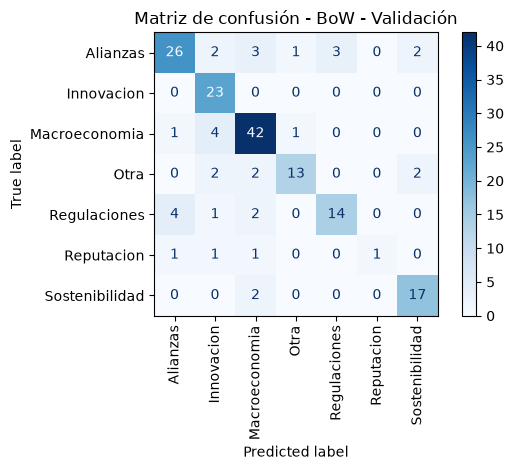

In [59]:
#construimos la matriz de confusion del modelo BoW sobre validacion
#las filas representan las categorias reales y las columnas las predicciones
#la diagonal muestra las noticias clasificadas correctamente
#esto permite observar en que categorias se esta confundiendo el modelo

matriz_confusion_bow = confusion_matrix(
    y_validacion,
    pred_bow_validacion,
    labels=categorias
)

disp_bow = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_bow,
    display_labels=categorias
)

disp_bow.plot(
    xticks_rotation=90,
    cmap="Blues"
)

plt.title("Matriz de confusión - BoW - Validación")
plt.tight_layout()
plt.show()

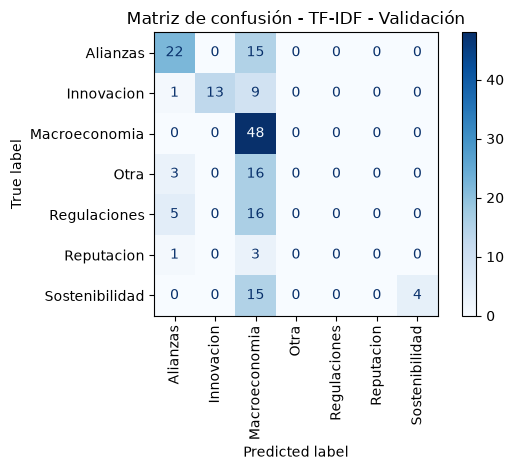

In [60]:
#construimos la matriz de confusion del modelo TF-IDF sobre validacion
#utilizamos las mismas categorias y formato que en el modelo BoW
#esto facilita comparar los errores de clasificacion entre ambos modelos
#los valores de la diagonal corresponden a las predicciones correctas

matriz_confusion_tfidf = confusion_matrix(
    y_validacion,
    pred_tfidf_validacion,
    labels=categorias
)

disp_tfidf = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_tfidf,
    display_labels=categorias
)

disp_tfidf.plot(
    xticks_rotation=90,
    cmap="Blues"
)

plt.title("Matriz de confusión - TF-IDF - Validación")
plt.tight_layout()
plt.show()

In [61]:
#creamos una funcion para extraer las metricas principales del classification_report
#guardamos accuracy, precision, recall y F1 tanto macro como ponderado
#despues evaluamos los dos modelos sobre entrenamiento y validacion
#esto permite comparar los resultados en una sola tabla

def obtener_metricas(y_real, y_predicho):
    reporte = classification_report(
        y_real,
        y_predicho,
        output_dict=True,
        zero_division=0
    )

    return {
        "accuracy": reporte["accuracy"],
        "precision_macro": reporte["macro avg"]["precision"],
        "recall_macro": reporte["macro avg"]["recall"],
        "f1_macro": reporte["macro avg"]["f1-score"],
        "precision_ponderado": reporte["weighted avg"]["precision"],
        "recall_ponderado": reporte["weighted avg"]["recall"],
        "f1_ponderado": reporte["weighted avg"]["f1-score"]
    }


resultados_validacion = pd.DataFrame([
    {
        "modelo": "BoW",
        "conjunto": "Entrenamiento",
        **obtener_metricas(
            y_entrenamiento,
            pred_bow_entrenamiento
        )
    },
    {
        "modelo": "BoW",
        "conjunto": "Validacion",
        **obtener_metricas(
            y_validacion,
            pred_bow_validacion
        )
    },
    {
        "modelo": "TF-IDF",
        "conjunto": "Entrenamiento",
        **obtener_metricas(
            y_entrenamiento,
            pred_tfidf_entrenamiento
        )
    },
    {
        "modelo": "TF-IDF",
        "conjunto": "Validacion",
        **obtener_metricas(
            y_validacion,
            pred_tfidf_validacion
        )
    }
])

display(
    resultados_validacion.round(4)
)

,modelo,conjunto,accuracy,precision_macro,recall_macro,f1_macro,precision_ponderado,recall_ponderado,f1_ponderado
0,BoW,Entrenamiento,0.9509,0.9581,0.9240,0.9368,0.9561,0.9509,0.9512
1,BoW,Validacion,0.7953,0.8310,0.7248,0.7381,0.8070,0.7953,0.7886
2,TF-IDF,Entrenamiento,0.6881,0.7509,0.5144,0.5202,0.7942,0.6881,0.6370
3,TF-IDF,Validacion,0.5088,0.4401,0.3386,0.3246,0.5048,0.5088,0.4323


In [62]:
#comparamos el accuracy de entrenamiento contra el accuracy de validacion
#una diferencia grande puede ser una señal de overfitting
#si ambos resultados son similares, el modelo esta generalizando mejor
#guardamos tambien la diferencia para facilitar la comparacion

comparacion_generalizacion = pd.DataFrame({
    "modelo": [
        "BoW",
        "TF-IDF"
    ],
    "accuracy_entrenamiento": [
        resultados_validacion.loc[
            (resultados_validacion["modelo"] == "BoW")
            & (resultados_validacion["conjunto"] == "Entrenamiento"),
            "accuracy"
        ].iloc[0],

        resultados_validacion.loc[
            (resultados_validacion["modelo"] == "TF-IDF")
            & (resultados_validacion["conjunto"] == "Entrenamiento"),
            "accuracy"
        ].iloc[0]
    ],
    "accuracy_validacion": [
        resultados_validacion.loc[
            (resultados_validacion["modelo"] == "BoW")
            & (resultados_validacion["conjunto"] == "Validacion"),
            "accuracy"
        ].iloc[0],

        resultados_validacion.loc[
            (resultados_validacion["modelo"] == "TF-IDF")
            & (resultados_validacion["conjunto"] == "Validacion"),
            "accuracy"
        ].iloc[0]
    ]
})

comparacion_generalizacion["diferencia"] = (
    comparacion_generalizacion["accuracy_entrenamiento"]
    - comparacion_generalizacion["accuracy_validacion"]
)

display(
    comparacion_generalizacion.round(4)
)

,modelo,accuracy_entrenamiento,accuracy_validacion,diferencia
0,BoW,0.9509,0.7953,0.1556
1,TF-IDF,0.6881,0.5088,0.1793


In [63]:
#comparamos ambos modelos utilizando el F1 macro de validacion
#el F1 macro le da la misma importancia a todas las categorias
#esto es util porque el corpus puede tener categorias con diferente cantidad de noticias
#seleccionamos el modelo con el valor mas alto

f1_bow_validacion = resultados_validacion.loc[
    (resultados_validacion["modelo"] == "BoW")
    & (resultados_validacion["conjunto"] == "Validacion"),
    "f1_macro"
].iloc[0]

f1_tfidf_validacion = resultados_validacion.loc[
    (resultados_validacion["modelo"] == "TF-IDF")
    & (resultados_validacion["conjunto"] == "Validacion"),
    "f1_macro"
].iloc[0]

if f1_bow_validacion > f1_tfidf_validacion:
    mejor_modelo_validacion = "BoW"
elif f1_tfidf_validacion > f1_bow_validacion:
    mejor_modelo_validacion = "TF-IDF"
else:
    mejor_modelo_validacion = "Empate"

print("Mejor modelo en validacion:", mejor_modelo_validacion)
print("F1 macro BoW:", round(f1_bow_validacion, 4))
print("F1 macro TF-IDF:", round(f1_tfidf_validacion, 4))

Mejor modelo en validacion: BoW
F1 macro BoW: 0.7381
F1 macro TF-IDF: 0.3246


In [64]:
#realizamos la evaluacion final sobre el conjunto de prueba
#este conjunto no fue utilizado para entrenar ni seleccionar los modelos
#por lo tanto nos permite estimar el desempeño sobre datos realmente desconocidos
#evaluamos nuevamente BoW y TF-IDF utilizando las mismas metricas

pred_bow_prueba = modelo_bow.predict(
    matriz_bow_prueba
)

pred_tfidf_prueba = modelo_tfidf.predict(
    matriz_tfidf_prueba
)

print("BoW - Prueba")
print(
    classification_report(
        y_prueba,
        pred_bow_prueba,
        labels=categorias,
        zero_division=0
    )
)

print("TF-IDF - Prueba")
print(
    classification_report(
        y_prueba,
        pred_tfidf_prueba,
        labels=categorias,
        zero_division=0
    )
)

BoW - Prueba
                precision    recall  f1-score   support

      Alianzas       0.78      0.78      0.78        37
    Innovacion       0.72      1.00      0.84        23
 Macroeconomia       0.86      0.92      0.89        48
          Otra       0.88      0.35      0.50        20
  Regulaciones       0.94      0.71      0.81        21
    Reputacion       1.00      0.25      0.40         4
Sostenibilidad       0.65      0.94      0.77        18

      accuracy                           0.80       171
     macro avg       0.83      0.71      0.71       171
  weighted avg       0.82      0.80      0.78       171

TF-IDF - Prueba
                precision    recall  f1-score   support

      Alianzas       0.70      0.76      0.73        37
    Innovacion       0.95      0.78      0.86        23
 Macroeconomia       0.43      1.00      0.60        48
          Otra       0.00      0.00      0.00        20
  Regulaciones       0.00      0.00      0.00        21
    Reputacion 

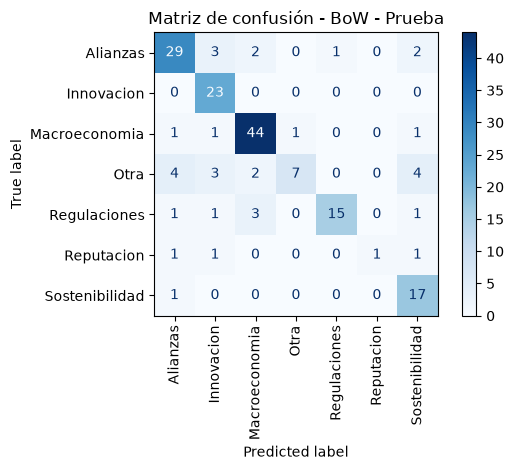

In [65]:
#construimos la matriz de confusion final del modelo BoW
#utilizamos ahora las predicciones realizadas sobre el conjunto de prueba
#esto permite identificar las categorias que el modelo confunde en datos nuevos
#las categorias se mantienen en el mismo orden utilizado anteriormente

matriz_confusion_bow_prueba = confusion_matrix(
    y_prueba,
    pred_bow_prueba,
    labels=categorias
)

disp_bow_prueba = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_bow_prueba,
    display_labels=categorias
)

disp_bow_prueba.plot(
    xticks_rotation=90,
    cmap="Blues"
)

plt.title("Matriz de confusión - BoW - Prueba")
plt.tight_layout()
plt.show()

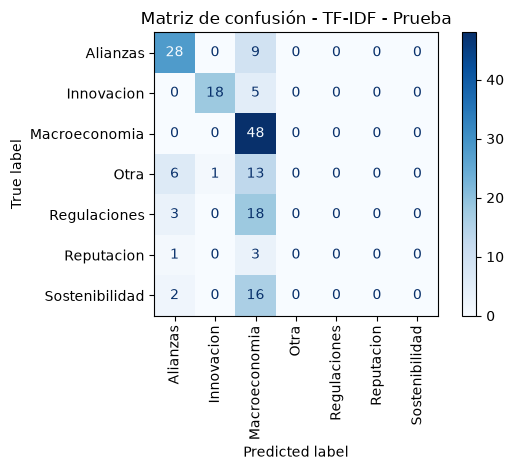

In [66]:
#construimos la matriz de confusion final del modelo TF-IDF
#la evaluacion se realiza sobre exactamente el mismo conjunto de prueba
#esto permite realizar una comparacion directa con el modelo basado en BoW
#observamos principalmente la diagonal y las categorias con mayor confusion

matriz_confusion_tfidf_prueba = confusion_matrix(
    y_prueba,
    pred_tfidf_prueba,
    labels=categorias
)

disp_tfidf_prueba = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_tfidf_prueba,
    display_labels=categorias
)

disp_tfidf_prueba.plot(
    xticks_rotation=90,
    cmap="Blues"
)

plt.title("Matriz de confusión - TF-IDF - Prueba")
plt.tight_layout()
plt.show()

In [67]:
#guardamos las metricas obtenidas sobre el conjunto de prueba
#despues las combinamos con los resultados de entrenamiento y validacion,
#la tabla final facilita comparar ambos modelos y observar su generalizacion

resultados_prueba = pd.DataFrame([
    {
        "modelo": "BoW",
        "conjunto": "Prueba",
        **obtener_metricas(
            y_prueba,
            pred_bow_prueba
        )
    },
    {
        "modelo": "TF-IDF",
        "conjunto": "Prueba",
        **obtener_metricas(
            y_prueba,
            pred_tfidf_prueba
        )
    }
])

resultados_finales = pd.concat(
    [
        resultados_validacion,
        resultados_prueba
    ],
    ignore_index=True
)

display(
    resultados_finales.round(4)
)

,modelo,conjunto,accuracy,precision_macro,recall_macro,f1_macro,precision_ponderado,recall_ponderado,f1_ponderado
0,BoW,Entrenamiento,0.9509,0.9581,0.9240,0.9368,0.9561,0.9509,0.9512
1,BoW,Validacion,0.7953,0.8310,0.7248,0.7381,0.8070,0.7953,0.7886
2,TF-IDF,Entrenamiento,0.6881,0.7509,0.5144,0.5202,0.7942,0.6881,0.6370
3,TF-IDF,Validacion,0.5088,0.4401,0.3386,0.3246,0.5048,0.5088,0.4323
4,BoW,Prueba,0.7953,0.8331,0.7085,0.7132,0.8181,0.7953,0.7803
5,TF-IDF,Prueba,0.5497,0.2966,0.3628,0.3121,0.3992,0.5497,0.4411


BoW obtuvo el mejor desempeño. En validación alcanzó un F1 macro de 0.7381, frente a 0.3246 de TF-IDF. En prueba también fue superior, con 0.80 de accuracy frente a 0.55.

Esto puede deberse a que BoW conserva directamente la frecuencia de las palabras, lo cual funciona bien con Multinomial Naive Bayes. TF-IDF reduce el peso de palabras frecuentes y aumenta el de términos más específicos, pero en este corpus esa ponderación parece haber reducido información útil para distinguir varias categorías.

**4. Análisis de errores del mejor modelo**

In [68]:
#utilizamos la matriz de confusion del mejor modelo, que en este caso fue BoW
#ponemos la diagonal en cero porque no nos interesan las clasificaciones correctas
#sumamos los errores en ambas direcciones para encontrar las dos categorias
#que el modelo confunde con mayor frecuencia entre si

confusiones = matriz_confusion_bow_prueba.copy()
np.fill_diagonal(confusiones, 0)

mayor_confusion = 0
par_confundido = None

for i in range(len(categorias)):
    for j in range(i + 1, len(categorias)):
        total_confusiones = (
            confusiones[i, j]
            + confusiones[j, i]
        )

        if total_confusiones > mayor_confusion:
            mayor_confusion = total_confusiones
            par_confundido = (
                categorias[i],
                categorias[j]
            )

categoria_1, categoria_2 = par_confundido

print("Categorias mas confundidas:")
print(categoria_1, "<->", categoria_2)
print("Cantidad de confusiones:", mayor_confusion)

Categorias mas confundidas:
Alianzas <-> Otra
Cantidad de confusiones: 4


In [69]:
#recuperamos los documentos originales correspondientes al conjunto de prueba
#agregamos tanto la categoria real como la prediccion realizada por BoW
#despues filtramos solamente los errores entre las dos categorias identificadas
#mostramos hasta 5 documentos para poder revisar manualmente su contenido

errores_prueba = corpus.loc[
    y_prueba.index,
    [TEXT_COL, CATEGORY_COL]
].copy()

errores_prueba["prediccion"] = pred_bow_prueba

errores_categorias = errores_prueba[
    (
        (errores_prueba[CATEGORY_COL] == categoria_1)
        & (errores_prueba["prediccion"] == categoria_2)
    )
    |
    (
        (errores_prueba[CATEGORY_COL] == categoria_2)
        & (errores_prueba["prediccion"] == categoria_1)
    )
]

display(
    errores_categorias[
        [
            CATEGORY_COL,
            "prediccion",
            TEXT_COL
        ]
    ].head(5)
)

,Type,prediccion,news
607,Otra,Alianzas,Bbva en Colombia a través de sus iniciativas de Responsabilidad Corporativa ha apoyado a la Fundación CreeSer ubicada en el barrio Altos de Menga ...
337,Otra,Alianzas,La Fundación Microfinanzas Bbva presentó una proyecto piloto para facilitar el acceso a internet a través de satélites en corresponsales bancarios...
1057,Otra,Alianzas,A través de una rueda de prensa Mario Pardo presidente de Bbva en Colombia anunció que la entidad financiera invertirá más de 7.800 millones en i...
730,Otra,Alianzas,Bbva y Bancolombia anunciaron la coestructuración y firma de un crédito para financiar la fase previa de la primera línea del Metro de Bogotá por ...


In [70]:
#analizamos que palabras de cada documento pudieron favorecer la categoria incorrecta
#comparamos la probabilidad aprendida de cada palabra para la clase predicha y la real
#una diferencia positiva indica que esa palabra favorecio mas a la prediccion incorrecta
#mostramos las palabras con mayor contribucion para cada documento seleccionado

vocabulario_bow = vectorizador_bow.get_feature_names_out()

for indice in errores_categorias.head(5).index:

    posicion_prueba = list(y_prueba.index).index(indice)

    categoria_real = y_prueba.loc[indice]
    categoria_predicha = pred_bow_prueba[posicion_prueba]

    indice_real = np.where(
        modelo_bow.classes_ == categoria_real
    )[0][0]

    indice_predicho = np.where(
        modelo_bow.classes_ == categoria_predicha
    )[0][0]

    vector_documento = matriz_bow_prueba[
        posicion_prueba
    ].toarray().ravel()

    diferencia = (
        modelo_bow.feature_log_prob_[indice_predicho]
        - modelo_bow.feature_log_prob_[indice_real]
    )

    contribucion = vector_documento * diferencia

    indices_palabras = np.argsort(
        contribucion
    )[::-1]

    indices_palabras = [
        i for i in indices_palabras
        if contribucion[i] > 0
    ][:8]

    palabras = vocabulario_bow[
        indices_palabras
    ].tolist()

    print("\nCategoria real:", categoria_real)
    print("Prediccion:", categoria_predicha)
    print("Palabras que favorecieron la prediccion:")
    print(palabras)


Categoria real: Otra
Prediccion: Alianzas
Palabras que favorecieron la prediccion:
['oficio', 'programa', 'educativo', 'iniciativo', 'niño', 'maría', 'proceso', 'brindar']

Categoria real: Otra
Prediccion: Alianzas
Palabras que favorecieron la prediccion:
['facilitar', 'microsoft', 'madrid', 'conexión', 'urbano', 'desarrollo', 'situación', 'acceso']

Categoria real: Otra
Prediccion: Alianzas
Palabras que favorecieron la prediccion:
['programa', 'educación', 'capacitación', 'colombiano', 'capacitar', 'pacífico', 'alianza', 'anunciar']

Categoria real: Otra
Prediccion: Alianzas
Palabras que favorecieron la prediccion:
['proyecto', 'calle', 'obra', 'promover', 'sostener', 'detalle', 'materia', 'juan']


In [71]:
#MultinomialNB guarda la verosimilitud de cada palabra como log P(w_i|c)
#convertimos estas probabilidades logaritmicas nuevamente a probabilidades normales
#analizamos las dos categorias que el modelo confundio con mayor frecuencia
#para cada categoria mostramos las 15 palabras con mayor P(w_i|c)

probabilidades_palabras = np.exp(
    modelo_bow.feature_log_prob_
)

for categoria in [
    categoria_1,
    categoria_2
]:

    indice_categoria = np.where(
        modelo_bow.classes_ == categoria
    )[0][0]

    probabilidades = probabilidades_palabras[
        indice_categoria
    ]

    indices_top = probabilidades.argsort()[
        ::-1
    ][:15]

    palabras_categoria = pd.DataFrame({
        "palabra": vocabulario_bow[indices_top],
        "P(w_i|c)": probabilidades[indices_top]
    })

    display(
        palabras_categoria.style
        .hide(axis="index")
        .set_caption(
            f"Palabras con mayor P(w_i|c) - {categoria}"
        )
    )

palabra,P(w_i|c)
alianza,0.005165
poder,0.004160
país,0.003613
millón,0.003437
él,0.003190
colombia,0.003120
empresa,0.003085
nuevo,0.002944
año,0.002926
hacer,0.002679


palabra,P(w_i|c)
bbva,0.006013
banco,0.005703
millón,0.004677
año,0.003532
financiero,0.003341
entidad,0.003269
crédito,0.002863
poder,0.002792
cliente,0.002482
tasa,0.002458


El supuesto de independencia condicional pudo contribuir a los errores entre Otra y Alianzas. Los cuatro documentos fueron clasificados como Alianzas porque contenian palabras como programa, proyecto, desarrollo, educación, alianza y acceso, que individualmente favorecen esa categoria. El problema es que Naive Bayes considera el aporte de cada palabra de forma independiente y no analiza suficientemente como se relacionan entre si dentro del contexto completo. Por ejemplo, una noticia puede mencionar un proyecto o programa sin que su tema principal sea una alianza. Al acumular estas palabras como evidencia separada, el modelo puede favorecer Alianzas aunque el documento realmente pertenezca a Otra.

**5. Efecto de la representación de texto**

In [72]:
#creamos una funcion para entrenar las nuevas variantes de BoW
#utilizamos exactamente el mismo procesamiento del modelo original
#el vectorizador se ajusta solamente con entrenamiento y validacion solo se transforma
#medimos solamente el tiempo de entrenamiento de MultinomialNB para poder compararlo

from time import perf_counter

def entrenar_variante_bow(
    nombre,
    max_features=None,
    ngram_range=(1, 1)
):

    vectorizador = CountVectorizer(
        tokenizer=str.split,
        token_pattern=None,
        lowercase=False,
        max_features=max_features,
        ngram_range=ngram_range
    )

    matriz_entrenamiento = vectorizador.fit_transform(
        X_entrenamiento
    )

    matriz_validacion = vectorizador.transform(
        X_validacion
    )

    modelo = MultinomialNB()

    inicio = perf_counter()

    modelo.fit(
        matriz_entrenamiento,
        y_entrenamiento
    )

    tiempo_entrenamiento = perf_counter() - inicio

    prediccion = modelo.predict(
        matriz_validacion
    )

    metricas = obtener_metricas(
        y_validacion,
        prediccion
    )

    resultado = {
        "representacion": nombre,
        "vocabulario": matriz_entrenamiento.shape[1],
        "accuracy": metricas["accuracy"],
        "f1_macro": metricas["f1_macro"],
        "tiempo_entrenamiento_s": tiempo_entrenamiento
    }

    return resultado, vectorizador, modelo, prediccion

In [73]:
#entrenamos BoW limitando el vocabulario a las palabras mas frecuentes
#probamos primero 1000 palabras y despues 5000 palabras
#ambos modelos utilizan el mismo conjunto de entrenamiento y validacion
#esto permite comparar directamente el efecto de reducir el vocabulario

resultado_bow_1000, vectorizador_bow_1000, modelo_bow_1000, pred_bow_1000 = (
    entrenar_variante_bow(
        "BoW 1000",
        max_features=1000
    )
)

resultado_bow_5000, vectorizador_bow_5000, modelo_bow_5000, pred_bow_5000 = (
    entrenar_variante_bow(
        "BoW 5000",
        max_features=5000
    )
)

display(
    pd.DataFrame([
        resultado_bow_1000,
        resultado_bow_5000
    ]).round(4)
)

,representacion,vocabulario,accuracy,f1_macro,tiempo_entrenamiento_s
0,BoW 1000,1000,0.8304,0.8493,0.0130
1,BoW 5000,5000,0.8363,0.8540,0.0133


In [74]:
#entrenamos una nueva variante utilizando unigramas y bigramas
#los unigramas representan palabras individuales y los bigramas pares consecutivos
#esto permite conservar un poco mas de contexto dentro de la representacion
#tambien esperamos un aumento importante en el tamaño del vocabulario

resultado_bow_bigramas, vectorizador_bow_bigramas, modelo_bow_bigramas, pred_bow_bigramas = (
    entrenar_variante_bow(
        "BoW unigramas + bigramas",
        ngram_range=(1, 2)
    )
)

display(
    pd.DataFrame([
        resultado_bow_bigramas
    ]).round(4)
)

,representacion,vocabulario,accuracy,f1_macro,tiempo_entrenamiento_s
0,BoW unigramas + bigramas,186332,0.7602,0.6566,0.0619


In [75]:
#el BoW completo ya fue construido y evaluado anteriormente
#no repetimos la vectorizacion ni sus predicciones porque ya existen
#solamente repetimos el fit de Naive Bayes para obtener un tiempo comparable
#con el modelo de unigramas y bigramas

modelo_bow_tiempo = MultinomialNB()

inicio = perf_counter()

modelo_bow_tiempo.fit(
    matriz_bow_entrenamiento,
    y_entrenamiento
)

tiempo_bow_completo = perf_counter() - inicio

metricas_bow_existente = resultados_validacion[
    (resultados_validacion["modelo"] == "BoW")
    & (resultados_validacion["conjunto"] == "Validacion")
].iloc[0]

resultado_bow_completo = {
    "representacion": "BoW completo",
    "vocabulario": matriz_bow_entrenamiento.shape[1],
    "accuracy": metricas_bow_existente["accuracy"],
    "f1_macro": metricas_bow_existente["f1_macro"],
    "tiempo_entrenamiento_s": tiempo_bow_completo
}

comparacion_bigramas = pd.DataFrame([
    resultado_bow_completo,
    resultado_bow_bigramas
])

display(
    comparacion_bigramas.round(4)
)

,representacion,vocabulario,accuracy,f1_macro,tiempo_entrenamiento_s
0,BoW completo,22066,0.7953,0.7381,0.0185
1,BoW unigramas + bigramas,186332,0.7602,0.6566,0.0619


In [76]:
#construimos la tabla final reutilizando los resultados que ya habiamos calculado
#BoW completo y TF-IDF no se vuelven a entrenar ni evaluar en esta celda
#las nuevas variantes corresponden a los experimentos realizados en esta seccion
#todas las metricas mostradas corresponden al mismo conjunto de validacion

metricas_tfidf_existente = resultados_validacion[
    (resultados_validacion["modelo"] == "TF-IDF")
    & (resultados_validacion["conjunto"] == "Validacion")
].iloc[0]

resultado_tfidf = {
    "representacion": "TF-IDF",
    "vocabulario": matriz_tfidf_entrenamiento.shape[1],
    "accuracy": metricas_tfidf_existente["accuracy"],
    "f1_macro": metricas_tfidf_existente["f1_macro"]
}

tabla_modelos = pd.DataFrame([
    {
        "representacion": resultado_bow_completo["representacion"],
        "vocabulario": resultado_bow_completo["vocabulario"],
        "accuracy": resultado_bow_completo["accuracy"],
        "f1_macro": resultado_bow_completo["f1_macro"]
    },
    {
        "representacion": resultado_bow_1000["representacion"],
        "vocabulario": resultado_bow_1000["vocabulario"],
        "accuracy": resultado_bow_1000["accuracy"],
        "f1_macro": resultado_bow_1000["f1_macro"]
    },
    {
        "representacion": resultado_bow_5000["representacion"],
        "vocabulario": resultado_bow_5000["vocabulario"],
        "accuracy": resultado_bow_5000["accuracy"],
        "f1_macro": resultado_bow_5000["f1_macro"]
    },
    {
        "representacion": resultado_bow_bigramas["representacion"],
        "vocabulario": resultado_bow_bigramas["vocabulario"],
        "accuracy": resultado_bow_bigramas["accuracy"],
        "f1_macro": resultado_bow_bigramas["f1_macro"]
    },
    resultado_tfidf
])

display(
    tabla_modelos.round(4)
)

,representacion,vocabulario,accuracy,f1_macro
0,BoW completo,22066,0.7953,0.7381
1,BoW 1000,1000,0.8304,0.8493
2,BoW 5000,5000,0.8363,0.8540
3,BoW unigramas + bigramas,186332,0.7602,0.6566
4,TF-IDF,22066,0.5088,0.3246
